# EDA + Preparación de datos (Bike Sharing)

"
"**Objetivo:** dejar el dataset claro (head, columnas, tipos, nulos) y preparar `X` / `y` sin fuga de información.

"
"Usamos los archivos locales `day.csv`

In [22]:
!pip install ucimlrepo
!pip install pandas scikit-learn streamlit joblib matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

##  Carga de datos (archivos locales)

In [24]:
import pandas as pd

df_day = pd.read_csv("../data/raw/day.csv")
df_hour = pd.read_csv("../data/raw/hour.csv")

df_day.shape, df_hour.shape

((731, 16), (17379, 17))

##  Vista rápida: `head`, columnas, tipos, nulos

In [25]:
# --- DAY ---
print("DAY shape:", df_day.shape)
print("\nDAY columns:\n", df_day.columns.tolist())
display(df_day.head(10))

DAY shape: (731, 16)

DAY columns:
 ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [26]:
# Tipos y nulos
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [27]:
# Estadísticos (numéricas)
display(df_day.describe().T)

,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000000,211.165812,1.000000,183.500000,366.000000,548.500000,731.000000
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
atemp,731.0,0.474354,0.162961,0.079070,0.337842,0.486733,0.608602,0.840896


In [28]:
# Nulos por columna (control rápido)
df_day.isna().sum().sort_values(ascending=False)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

##  Diccionario de variables (day.csv)

**Temporales / calendario**

"
"- `dteday`: fecha (string → la convertimos a datetime)
"
"- `yr`: año (0=2011, 1=2012)
"
"- `mnth`: mes (1–12)
"
"- `weekday`: día de semana (0–6)
"
"- `holiday`: festivo (0/1)
"
"- `workingday`: día laboral (0/1)

"
"**Categóricas codificadas (tratar como categóricas)**

"
"- `season`: estación (1–4)
"
"- `weathersit`: situación meteorológica (1–4)

"
"**Clima (normalizadas entre 0 y 1 en este dataset)**

"
"- `temp`: temperatura normalizada
"
"- `atemp`: sensación térmica normalizada
"
"- `hum`: humedad normalizada
"
"- `windspeed`: velocidad del viento normalizada

"
"**Demanda**

"
"- `casual`: usuarios casuales
"
"- `registered`: usuarios registrados
"
"- `cnt`: total diario (`casual` + `registered`)  ✅ **target**

"
"⚠️ Importante: `casual` y `registered` NO deben usarse como features para predecir `cnt` (sería fuga de información).

## Limpieza mínima + conversiones

In [29]:
# Convertir fecha
df_day["dteday"] = pd.to_datetime(df_day["dteday"])
df_hour["dteday"] = pd.to_datetime(df_hour["dteday"])

# Chequeo duplicados
print("Duplicados DAY:", df_day.duplicated().sum())
print("Duplicados HOUR:", df_hour.duplicated().sum())

df_day.head()


Duplicados DAY: 0
Duplicados HOUR: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## EDA básica del target (`cnt`)

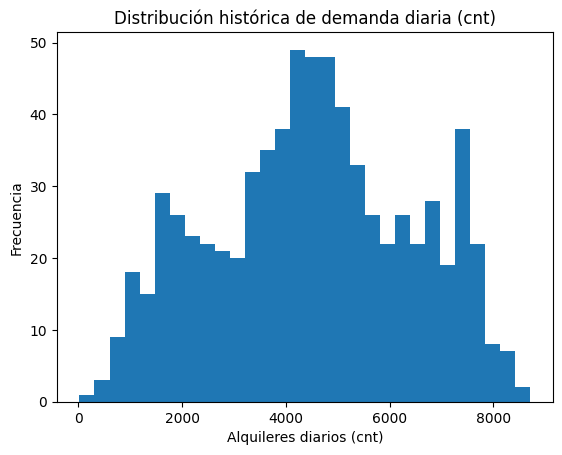

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

In [30]:
# Distribución del target
plt.figure()
plt.hist(df_day["cnt"], bins=30)
plt.title("Distribución histórica de demanda diaria (cnt)")
plt.xlabel("Alquileres diarios (cnt)")
plt.ylabel("Frecuencia")
plt.show()

df_day["cnt"].describe()


In [31]:
# Promedio por estación
season_mean = df_day.groupby("season")["cnt"].mean().sort_index()
season_mean

season
1    2604.132597
2    4992.331522
3    5644.303191
4    4728.162921
Name: cnt, dtype: float64

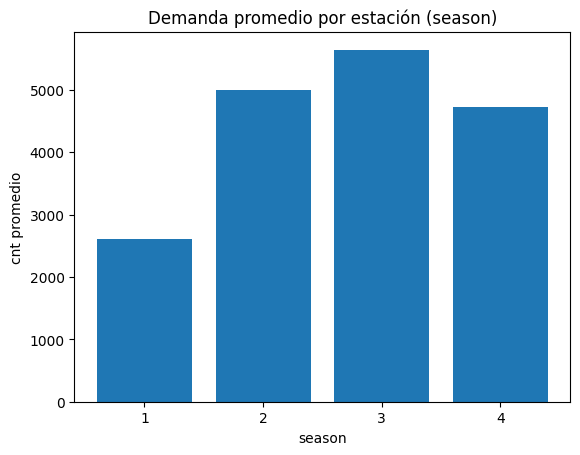

In [32]:
plt.figure()
plt.bar(season_mean.index.astype(str), season_mean.values)
plt.title("Demanda promedio por estación (season)")
plt.xlabel("season")
plt.ylabel("cnt promedio")
plt.show()


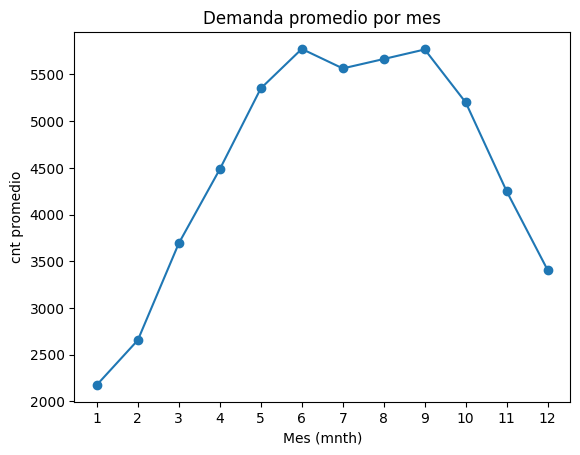

In [33]:
# Estacionalidad por mes
mnth_mean = df_day.groupby("mnth")["cnt"].mean().sort_index()
plt.figure()
plt.plot(mnth_mean.index, mnth_mean.values, marker="o")
plt.title("Demanda promedio por mes")
plt.xlabel("Mes (mnth)")
plt.ylabel("cnt promedio")
plt.xticks(mnth_mean.index)
plt.show()

## Correlaciones (para entender señales)

In [34]:
# Correlación solo numéricas
num_cols = df_day.select_dtypes(include=[np.number]).columns
corr = df_day[num_cols].corr(numeric_only=True)

# Mostrar top correlaciones con cnt (excepto cnt mismo)
corr["cnt"].drop("cnt").sort_values(ascending=False).head(10)

registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
Name: cnt, dtype: float64

## Preparación de `X` / `y` (sin leakage)

In [36]:
TARGET = "cnt"
LEAK_COLS = ["casual", "registered"]
DROP_ALWAYS = ["instant", "dteday"]  # identificador + fecha cruda (la fecha ya se representa con variables de calendario)

feature_cols = [c for c in df_day.columns if c not in [TARGET] + LEAK_COLS + DROP_ALWAYS]

X = df_day[feature_cols].copy()
y = df_day[TARGET].copy()

print("Features:", X.columns.tolist())
print("X shape:", X.shape, "| y shape:", y.shape)

display(X.head())


Features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X shape: (731, 11) | y shape: (731,)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900


### La pagina del archivo:
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
### La pagina q hice con streamlit:
http://localhost:8501/